In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, f1_score

In [168]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [169]:
import os

BASE_PATH = "/content/drive/MyDrive/datasets_aligned"

print("BASE_PATH exists:", os.path.exists(BASE_PATH))
print("Files in folder:")
print(os.listdir(BASE_PATH))

BASE_PATH exists: True
Files in folder:
['NASDAQCOM.csv', 'GDPC1.csv', 'DFF_interest_rate.csv', 'CPIAUCSL.csv', 'data_gpr_daily_recent.CSV', 'multidim_LSTM_best.pth', 'multidim_LSTM_last.pth']


In [170]:
import pandas as pd

nasdaq = pd.read_csv(f"{BASE_PATH}/NASDAQCOM.csv")
cpi = pd.read_csv(f"{BASE_PATH}/CPIAUCSL.csv")
gdp = pd.read_csv(f"{BASE_PATH}/GDPC1.csv")
rate = pd.read_csv(f"{BASE_PATH}/DFF_interest_rate.csv")
gpr = pd.read_csv(f"{BASE_PATH}/data_gpr_daily_recent.CSV")

In [171]:
# Cell 5
print("NASDAQ columns:", nasdaq.columns.tolist())
print("CPI columns:", cpi.columns.tolist())
print("GDP columns:", gdp.columns.tolist())
print("Rate columns:", rate.columns.tolist())
print("GPR columns:", gpr.columns.tolist())

NASDAQ columns: ['date', 'NASDAQCOM']
CPI columns: ['date', 'cpi']
GDP columns: ['date', 'GDP']
Rate columns: ['date', 'DFF']
GPR columns: ['date', 'gpr']


In [172]:
# Cell 6
nasdaq["date"] = pd.to_datetime(nasdaq["date"])
cpi["date"] = pd.to_datetime(cpi["date"])
gdp["date"] = pd.to_datetime(gdp["date"])
rate["date"] = pd.to_datetime(rate["date"])
gpr["date"] = pd.to_datetime(gpr["date"])

nasdaq = nasdaq.rename(columns={"NASDAQCOM": "nasdaq"})
gdp = gdp.rename(columns={"GDP": "gdp"})
rate = rate.rename(columns={"DFF": "interest_rate"})

if "GPRD_MA7" in gpr.columns:
    gpr = gpr.rename(columns={"GPRD_MA7": "gpr"})
elif "gpr" in gpr.columns:
    pass
else:
    raise ValueError(f"Cannot find GPR column. Columns are: {gpr.columns.tolist()}")

gpr = gpr[["date", "gpr"]]

print("After rename:")
print("NASDAQ:", nasdaq.columns.tolist())
print("CPI:", cpi.columns.tolist())
print("GDP:", gdp.columns.tolist())
print("Rate:", rate.columns.tolist())
print("GPR:", gpr.columns.tolist())

After rename:
NASDAQ: ['date', 'nasdaq']
CPI: ['date', 'cpi']
GDP: ['date', 'gdp']
Rate: ['date', 'interest_rate']
GPR: ['date', 'gpr']


In [173]:
_df = nasdaq.merge(cpi, on="date", how="inner")
_df = _df.merge(gdp, on="date", how="inner")
_df = _df.merge(rate, on="date", how="inner")
_df = _df.merge(gpr, on="date", how="inner")

_df = _df.sort_values("date").reset_index(drop=True)

print(_df.head())
print(_df.tail())
print("Shape:", _df.shape)

        date  nasdaq    cpi      gdp  interest_rate     gpr
0 1985-01-01  246.63  105.7  8400.82           8.74  230.04
1 1985-01-02  245.91  105.7  8400.82           9.37  172.86
2 1985-01-03  246.41  105.7  8400.82           8.77  147.71
3 1985-01-04  246.19  105.7  8400.82           8.18  150.13
4 1985-01-05  246.14  105.7  8400.82           8.18  136.37
            date        nasdaq      cpi        gdp  interest_rate     gpr
14879 2025-09-27  22519.763333  324.245  24026.834           4.09  117.21
14880 2025-09-28  22555.456667  324.245  24026.834           4.09  112.72
14881 2025-09-29  22591.150000  324.245  24026.834           4.09  111.93
14882 2025-09-30  22660.010000  324.245  24026.834           4.09  116.06
14883 2025-10-01  22755.160000  324.245  24065.956           4.09  121.91
Shape: (14884, 6)


In [174]:
df = _df.copy()

# base return
returns = df["nasdaq"].pct_change() * 100  # Convert to percentage

# dynamic external
df["rate_change"] = df["interest_rate"].diff()

# target (next day) return
target = returns.shift(-1)

# Multi-task targets
df["target_magnitude"] = target.abs()  # Absolute value of return
df["target_direction"] = (target > 0).astype(float)  # 1.0 if up, 0.0 if down/flat

# Input features: decompose return into magnitude and direction
df["return_magnitude"] = returns.abs()  # Absolute value
df["return_direction"] = (returns > 0).astype(float)  # 1.0 if up, 0.0 if down

df = df.dropna().reset_index(drop=True)


SAMPLE_INTERVAL = 1
df = df.iloc[::SAMPLE_INTERVAL].reset_index(drop=True)

seq_feature_cols = [
    "return_magnitude",
    "return_direction",
    "gpr",
    "rate_change",
]

print(df.head())
print(df.shape)

        date  nasdaq    cpi      gdp  interest_rate     gpr  rate_change  \
0 1985-01-02  245.91  105.7  8400.82           9.37  172.86         0.63   
1 1985-01-03  246.41  105.7  8400.82           8.77  147.71        -0.60   
2 1985-01-04  246.19  105.7  8400.82           8.18  150.13        -0.59   
3 1985-01-05  246.14  105.7  8400.82           8.18  136.37         0.00   
4 1985-01-06  246.09  105.7  8400.82           8.18  141.53         0.00   

   target_magnitude  target_direction  return_magnitude  return_direction  
0          0.203326               1.0          0.291935               0.0  
1          0.089282               0.0          0.203326               1.0  
2          0.020310               0.0          0.089282               0.0  
3          0.020314               0.0          0.020310               0.0  
4          0.020318               0.0          0.020314               0.0  
(14882, 11)


In [175]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.9
WINDOW_SIZE = 10

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * VAL_RATIO)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 11905
Val size: 1488
Test size: 1489


In [176]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[seq_feature_cols])
val_scaled = scaler.transform(val_df[seq_feature_cols])
test_scaled = scaler.transform(test_df[seq_feature_cols])

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[seq_feature_cols] = train_scaled
val_df_scaled[seq_feature_cols] = val_scaled
test_df_scaled[seq_feature_cols] = test_scaled

In [177]:
class MultiFeatureSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, window_size=60):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.window_size = window_size

        self.X = self.df[feature_cols].values.astype(np.float32)
        self.y_mag = self.df["target_magnitude"].values.astype(np.float32)
        self.y_dir = self.df["target_direction"].values.astype(np.float32)

    def __len__(self):
        return len(self.df) - self.window_size

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window_size]
        y_mag = self.y_mag[idx + self.window_size - 1]
        y_dir = self.y_dir[idx + self.window_size - 1]

        x_seq = torch.tensor(x_seq)
        y_mag = torch.tensor(y_mag)
        y_dir = torch.tensor(y_dir)

        return x_seq, (y_mag, y_dir)

In [178]:
BATCH_SIZE = 128

train_dataset = MultiFeatureSequenceDataset(train_df_scaled, seq_feature_cols, WINDOW_SIZE)
val_dataset = MultiFeatureSequenceDataset(val_df_scaled, seq_feature_cols, WINDOW_SIZE)
test_dataset = MultiFeatureSequenceDataset(test_df_scaled, seq_feature_cols, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

print("train dataset:")
print(train_df_scaled)

Train dataset: 11895
Val dataset: 1478
Test dataset: 1479
train dataset:
            date       nasdaq      cpi        gdp  interest_rate       gpr  \
0     1985-01-02   245.910000  105.700   8400.820           9.37  0.179264   
1     1985-01-03   246.410000  105.700   8400.820           8.77  0.146901   
2     1985-01-04   246.190000  105.700   8400.820           8.18  0.150015   
3     1985-01-05   246.140000  105.700   8400.820           8.18  0.132309   
4     1985-01-06   246.090000  105.700   8400.820           8.18  0.138949   
...          ...          ...      ...        ...            ...       ...   
11900 2017-08-02  6362.650000  245.183  19660.766           1.16  0.117331   
11901 2017-08-03  6340.340000  245.183  19660.766           1.16  0.122581   
11902 2017-08-04  6351.560000  245.183  19660.766           1.16  0.119222   
11903 2017-08-05  6362.296667  245.183  19660.766           1.16  0.121307   
11904 2017-08-06  6373.033333  245.183  19660.766           1.16  0.1

In [179]:
class FeatureAttention(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Tanh(),
            nn.Linear(input_size, input_size)
        )

    def forward(self, x):
        # x: (batch, window, input_size)
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=-1)
        x_weighted = x * weights
        return x_weighted, weights


class TimeAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # lstm_out: (batch, window, hidden)
        scores = self.attn(lstm_out).squeeze(-1)      # (batch, window)
        weights = torch.softmax(scores, dim=1)        # (batch, window)
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        return context, weights


class FinalStage1Model(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=2, dropout=0.2, fc_hidden=64):
        super().__init__()

        self.feature_attention = FeatureAttention(input_size)

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )

        self.time_attention = TimeAttention(hidden_size)  # *2 for bidirectional

        # Magnitude head: predicts absolute value (continuous)
        self.magnitude_head = nn.Sequential(
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1),
            nn.ReLU()  # Ensure non-negative magnitude
        )

        # Direction head: predicts probability (0-1)
        self.direction_head = nn.Sequential(
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1),
            nn.Sigmoid()  # Output probability
        )

    def forward(self, x, return_attention=False):
        x_weighted, feature_weights = self.feature_attention(x)
        lstm_out, _ = self.lstm(x_weighted)
        context, time_weights = self.time_attention(lstm_out)

        mag_pred = self.magnitude_head(context).squeeze(-1)
        dir_pred = self.direction_head(context).squeeze(-1)

        if return_attention:
            return mag_pred, dir_pred, feature_weights, time_weights
        return mag_pred, dir_pred

In [180]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = FinalStage1Model(
    input_size=len(seq_feature_cols),
    hidden_size=256,
    num_layers=2,
    dropout=0.3,
    fc_hidden=64
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)



scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

Using device: cuda


In [181]:
mse_loss_fn = nn.MSELoss()
bce_loss_fn = nn.BCELoss()

def multi_task_loss(mag_pred, dir_pred, mag_target, dir_target, alpha=0.5, beta=0.5):
    """
    Multi-task loss combining magnitude and direction prediction.
    alpha: weight for magnitude loss (default 0.5)
    beta: weight for direction loss (default 0.5)
    """
    # Magnitude loss: MSE on absolute values
    mag_loss = mse_loss_fn(mag_pred, mag_target)
    
    # Direction loss: Binary cross entropy on probabilities
    dir_loss = bce_loss_fn(dir_pred, dir_target)

    # Combined loss: weighted sum (50% magnitude, 50% direction)
    return alpha * 10 *mag_loss + beta * dir_loss

In [182]:
EPOCHS = 50
EARLY_STOP_PATIENCE = 20

best_val_loss = float("inf")
best_state = None
no_improve = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for x_seq, (y_mag, y_dir) in train_loader:
        x_seq = x_seq.to(device)
        y_mag = y_mag.to(device)
        y_dir = y_dir.to(device)

        mag_pred, dir_pred = model(x_seq)
        loss = multi_task_loss(mag_pred, dir_pred, y_mag, y_dir)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x_seq, (y_mag, y_dir) in val_loader:
            x_seq = x_seq.to(device)
            y_mag = y_mag.to(device)
            y_dir = y_dir.to(device)

            mag_pred, dir_pred = model(x_seq)
            loss = multi_task_loss(mag_pred, dir_pred, y_mag, y_dir)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f}, Val Loss = {avg_val_loss:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= EARLY_STOP_PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

Epoch 1: Train Loss = 4.017708, Val Loss = 4.074130
Epoch 2: Train Loss = 3.847309, Val Loss = 3.839530
Epoch 3: Train Loss = 3.562553, Val Loss = 3.279178
Epoch 4: Train Loss = 3.295897, Val Loss = 3.165688
Epoch 5: Train Loss = 3.118984, Val Loss = 3.271953
Epoch 6: Train Loss = 3.157439, Val Loss = 3.203610
Epoch 7: Train Loss = 3.115466, Val Loss = 3.176080
Epoch 8: Train Loss = 3.050817, Val Loss = 3.172306
Epoch 9: Train Loss = 3.100483, Val Loss = 3.231075
Epoch 10: Train Loss = 3.050618, Val Loss = 3.159319
Epoch 11: Train Loss = 3.063551, Val Loss = 3.147920
Epoch 12: Train Loss = 3.022333, Val Loss = 3.131956
Epoch 13: Train Loss = 3.082878, Val Loss = 3.126393
Epoch 14: Train Loss = 3.099748, Val Loss = 3.313431
Epoch 15: Train Loss = 3.024788, Val Loss = 3.127445
Epoch 16: Train Loss = 3.007225, Val Loss = 3.351517
Epoch 17: Train Loss = 3.026582, Val Loss = 3.136757
Epoch 18: Train Loss = 2.993652, Val Loss = 3.114056
Epoch 19: Train Loss = 2.994162, Val Loss = 3.128451
Ep

<All keys matched successfully>

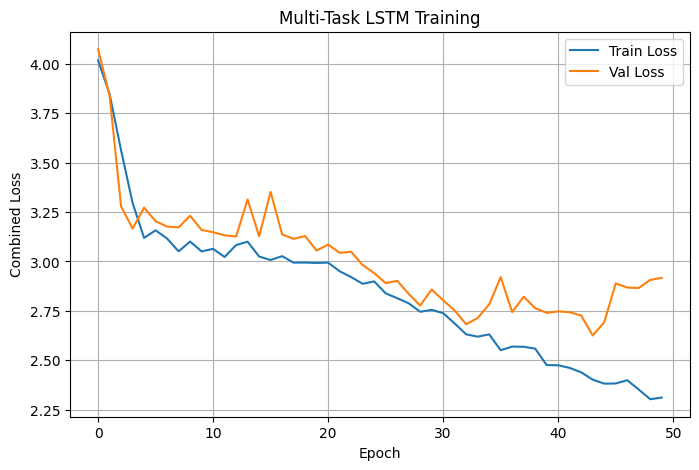

===== TEST RESULTS =====

--- MAGNITUDE HEAD ---
MSE: 0.61052537
MAE: 0.51015401

--- DIRECTION HEAD ---
Accuracy (0.5 threshold): 0.66328600
F1 Score: 0.72934783
AUC-ROC: 0.75111312


In [183]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.title("Multi-Task LSTM Training")
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import roc_auc_score

model.eval()

all_mag_preds = []
all_dir_preds = []
all_mag_targets = []
all_dir_targets = []

with torch.no_grad():
    for x_seq, (y_mag, y_dir) in test_loader:
        x_seq = x_seq.to(device)
        mag_pred, dir_pred = model(x_seq)
        
        all_mag_preds.append(mag_pred.cpu().numpy())
        all_dir_preds.append(dir_pred.cpu().numpy())
        all_mag_targets.append(y_mag.numpy())
        all_dir_targets.append(y_dir.numpy())

mag_preds = np.concatenate(all_mag_preds)
dir_preds = np.concatenate(all_dir_preds)
mag_targets = np.concatenate(all_mag_targets)
dir_targets = np.concatenate(all_dir_targets)

# Magnitude metrics
mag_mse = np.mean((mag_preds - mag_targets) ** 2)
mag_mae = mean_absolute_error(mag_targets, mag_preds)

# Direction metrics
dir_pred_binary = (dir_preds > 0.5).astype(int)
dir_accuracy = np.mean(dir_pred_binary == dir_targets)
dir_f1 = f1_score(dir_targets, dir_pred_binary)

# AUC-ROC for direction (using probabilities directly)
dir_auc = roc_auc_score(dir_targets, dir_preds)

print("===== TEST RESULTS =====")
print(f"\n--- MAGNITUDE HEAD ---")
print(f"MSE: {mag_mse:.8f}")
print(f"MAE: {mag_mae:.8f}")
print(f"\n--- DIRECTION HEAD ---")
print(f"Accuracy (0.5 threshold): {dir_accuracy:.8f}")
print(f"F1 Score: {dir_f1:.8f}")
print(f"AUC-ROC: {dir_auc:.8f}")

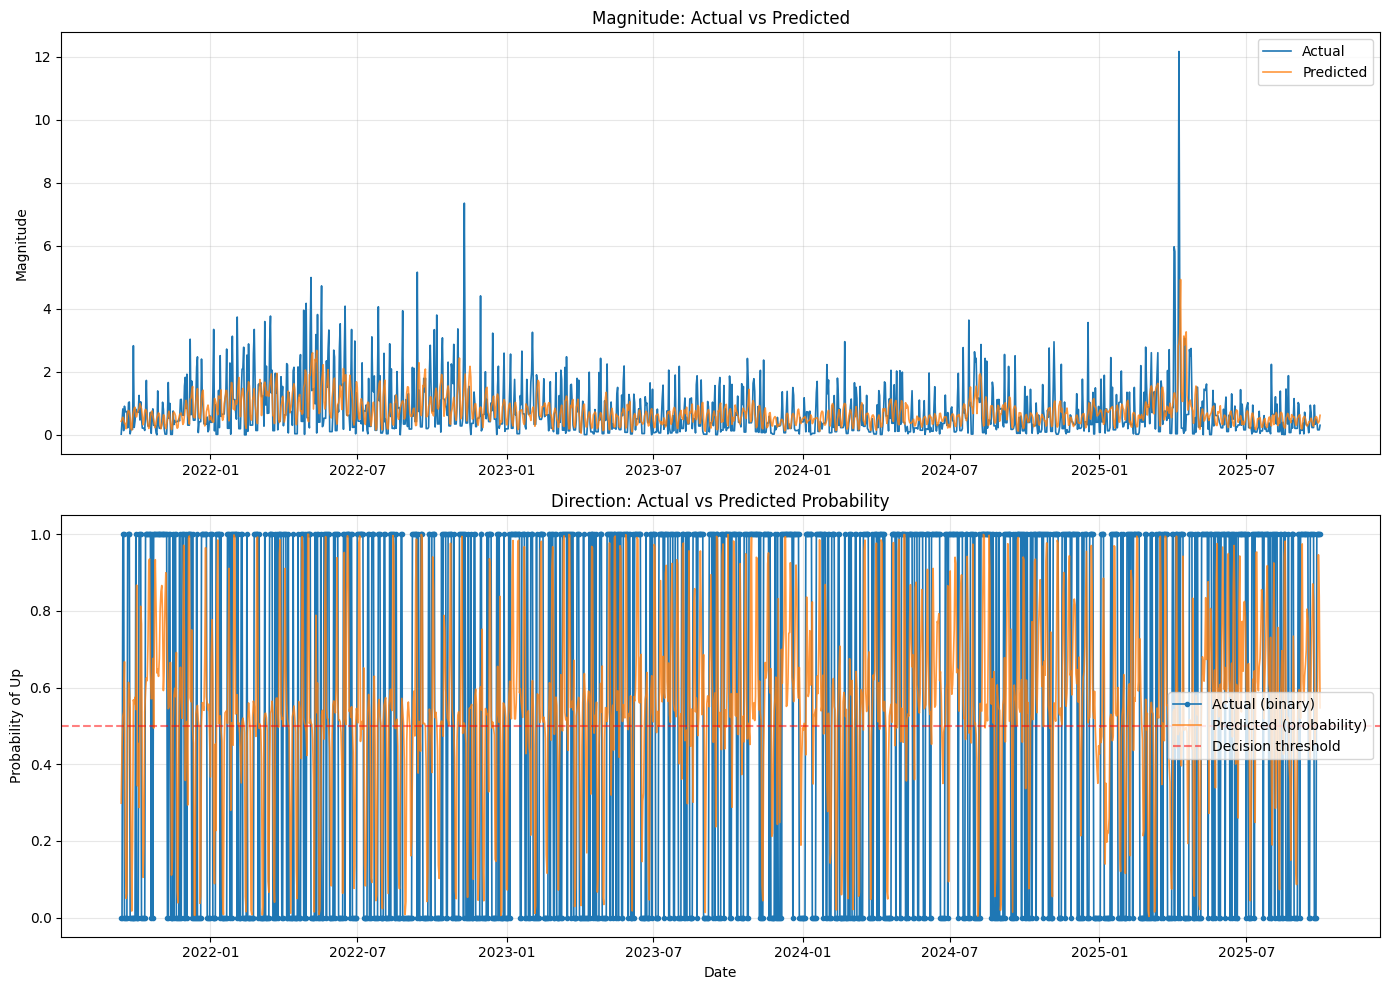

In [184]:
test_dates = test_df["date"].values[WINDOW_SIZE:WINDOW_SIZE + len(mag_preds)]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Magnitude predictions
axes[0].plot(test_dates, mag_targets, label="Actual", linewidth=1.2)
axes[0].plot(test_dates, mag_preds, label="Predicted", linewidth=1.2, alpha=0.8)
axes[0].set_title("Magnitude: Actual vs Predicted")
axes[0].set_ylabel("Magnitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Direction predictions (as probabilities)
axes[1].plot(test_dates, dir_targets, label="Actual (binary)", linewidth=1.2, marker='.')
axes[1].plot(test_dates, dir_preds, label="Predicted (probability)", linewidth=1.2, alpha=0.8)
axes[1].axhline(0.5, color='r', linestyle='--', alpha=0.5, label='Decision threshold')
axes[1].set_title("Direction: Actual vs Predicted Probability")
axes[1].set_ylabel("Probability of Up")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

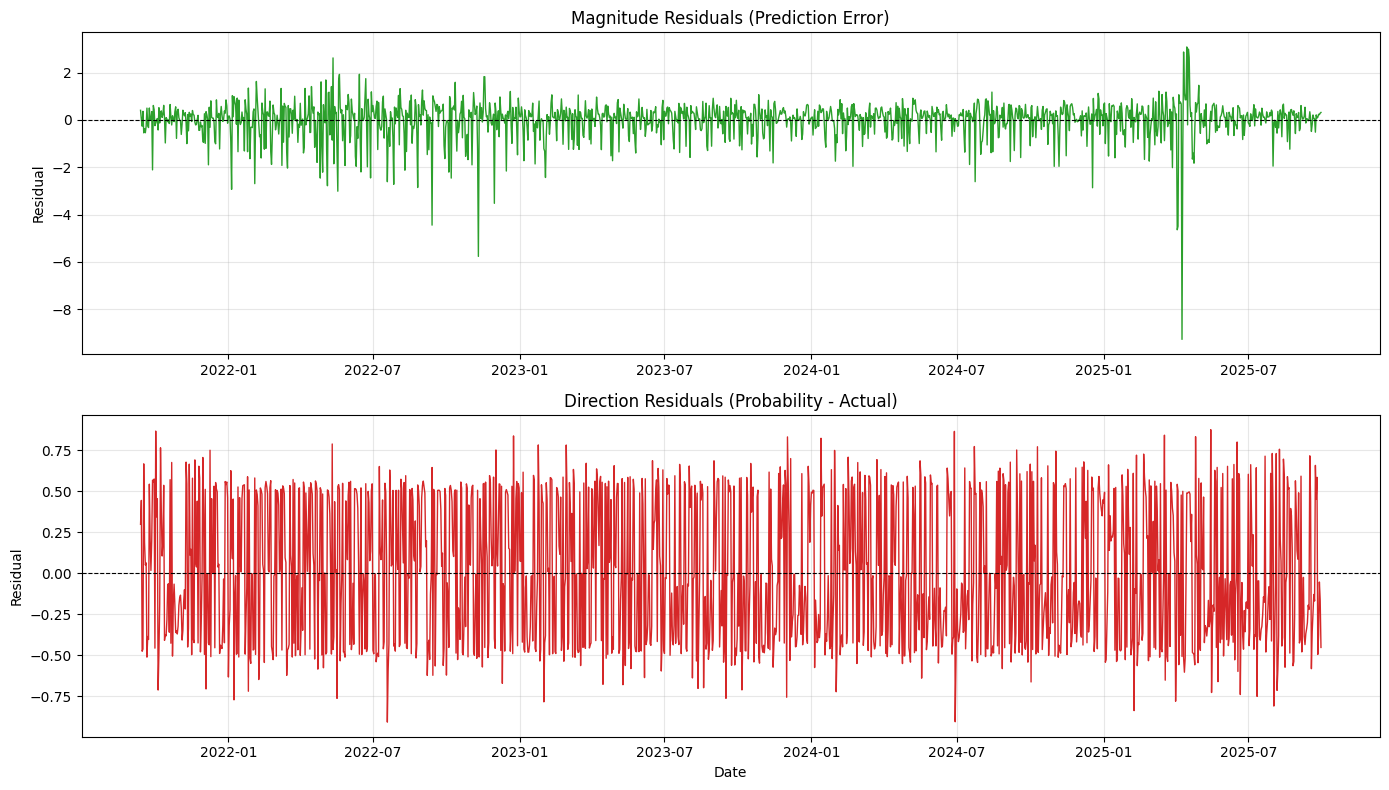

In [185]:
test_dates = test_df["date"].values[WINDOW_SIZE:WINDOW_SIZE + len(mag_preds)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Magnitude residuals
mag_residuals = mag_preds - mag_targets
axes[0].plot(test_dates, mag_residuals, linewidth=1.0, color='C2')
axes[0].axhline(0, linestyle="--", color='black', linewidth=0.8)
axes[0].set_title("Magnitude Residuals (Prediction Error)")
axes[0].set_ylabel("Residual")
axes[0].grid(True, alpha=0.3)

# Direction residuals
dir_residuals = dir_preds - dir_targets
axes[1].plot(test_dates, dir_residuals, linewidth=1.0, color='C3')
axes[1].axhline(0, linestyle="--", color='black', linewidth=0.8)
axes[1].set_title("Direction Residuals (Probability - Actual)")
axes[1].set_ylabel("Residual")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()